In [1]:
import numpy as np
import scipy 
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
import sys
import time
from distmesh import *
from FEM_TPT import *
sys.path.append('/Users/shashanksule/Documents/TMDmaps/')
import src.helpers as helpers



In [2]:
data = scipy.io.loadmat('DistmeshMuller_20.mat')
pts, committor, tr = data['pts'], data['committor'], data['tr']
beta = 1/20
Z = 124281.96427262
tr = tr - 1

In [3]:
def mueller(x):
    a = np.array([-1,-1,-6.5,0.7])
    b = np.array([0,0,11,0.6])
    c = np.array([-10,-10,-6.5,0.7])
    D = np.array([-200,-100,-170,15])
    X = np.array([1,0,-0.5,-1])
    Y = np.array([0,0.5,1.5,1])
  
    fx1 = D[0]*np.exp(a[0]*((x[:,0]-X[0])**(2)) + b[0]*(x[:,0]-X[0])*(x[:,1]-Y[0]) + c[0]*((x[:,1]-Y[0])**(2)))
    fx2 = D[1]*np.exp(a[1]*((x[:,0]-X[1])**(2)) + b[1]*(x[:,0]-X[1])*(x[:,1]-Y[1]) + c[1]*((x[:,1]-Y[1])**(2)))
    fx3 = D[2]*np.exp(a[2]*((x[:,0]-X[2])**(2)) + b[2]*(x[:,0]-X[2])*(x[:,1]-Y[2]) + c[2]*((x[:,1]-Y[2])**(2)))
    fx4 = D[3]*np.exp(a[3]*((x[:,0]-X[3])**(2)) + b[3]*(x[:,0]-X[3])*(x[:,1]-Y[3]) + c[3]*((x[:,1]-Y[3])**(2)))
    
    U = fx1+fx2+fx3+fx4
    return U

In [ ]:
Rcurrent, Rrate = reactive_current_and_transition_rate(pts,tr,mueller,beta,committor.squeeze(),Z)

In [17]:
# get metastable regions for muller 
metastables = helpers.throwing_pts_muller(pts.T, 100)
A_bool = metastables['A_bool']
B_bool = metastables['B_bool']

In [18]:
np.sum(A_bool), np.sum(B_bool)

(32, 38)

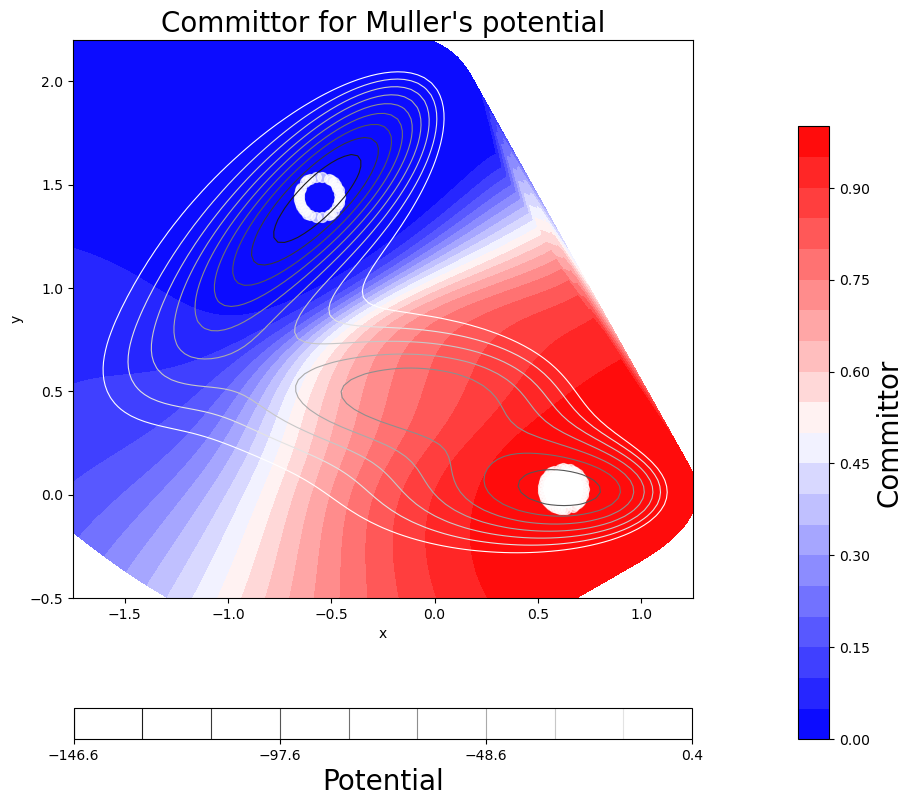

In [20]:
from scipy.interpolate import CloughTocher2DInterpolator
from scipy.spatial import Delaunay
from matplotlib.ticker import MaxNLocator

comm = np.asarray(committor).squeeze()
x, y = pts[:, 0], pts[:, 1]

# (a) Filled contour of committor on the point cloud (Delaunay triangulation)
fig_a, ax_a = plt.subplots(figsize=(10, 9))
tri_mesh = Delaunay(pts)
tc = ax_a.tricontourf(x, y, comm, levels=20, cmap="bwr")
ax_a.scatter(x[A_bool], y[A_bool], color='white', label='A', edgecolor='w', s=50, alpha=0.7)
ax_a.scatter(x[B_bool], y[B_bool], color='white', label='B', edgecolor='w', s=50, alpha=0.7)

# Muller potential level sets (same grid/levels style as helpers.plot_density)
nx, ny = 128, 128
xx = np.linspace(x.min(), x.max(), nx)
yy = np.linspace(y.min(), y.max(), ny)
XX, YY = np.meshgrid(xx, yy, indexing="xy")
potential_grid = np.vectorize(lambda a, b: helpers.muller_potential([a, b]))(XX, YY)
grid_min = np.min(potential_grid)
potential_levels = np.linspace(grid_min, 0.4, 10)
norm_pot = plt.Normalize(vmin=grid_min, vmax=0.4)
pot_cf = ax_a.contour(
    XX,
    YY,
    potential_grid,
    levels=potential_levels,
    cmap="gist_grey",
    norm=norm_pot,
    linewidths=0.8,
)
# Colorbars: committor (side) and potential (bottom), shortened vs. axes for readability
shrink = 0.78
cbar_com = fig_a.colorbar(tc, ax=ax_a, shrink=shrink, pad=0.02)
cbar_com.set_label("Committor", fontsize=20)
cbar_pot = fig_a.colorbar(
    pot_cf,
    ax=ax_a,
    orientation="horizontal",
    shrink=shrink,
    pad=0.14
)
cbar_pot.set_ticks(np.linspace(grid_min, 0.4, 4))
cbar_pot.set_label("Potential", fontsize=20)
ax_a.set_xlabel("x")
ax_a.set_ylabel("y")
ax_a.set_title(f"Committor for Muller's potential", fontsize=20)
ax_a.set_aspect("equal")
xmin, xmax = -1.75, 1.25
ymin, ymax = -0.5, 2.20
ax_a.set_xlim(xmin, xmax)
ax_a.set_ylim(ymin, ymax)
fig_a.tight_layout(rect=[0, 0.06, 1, 1])


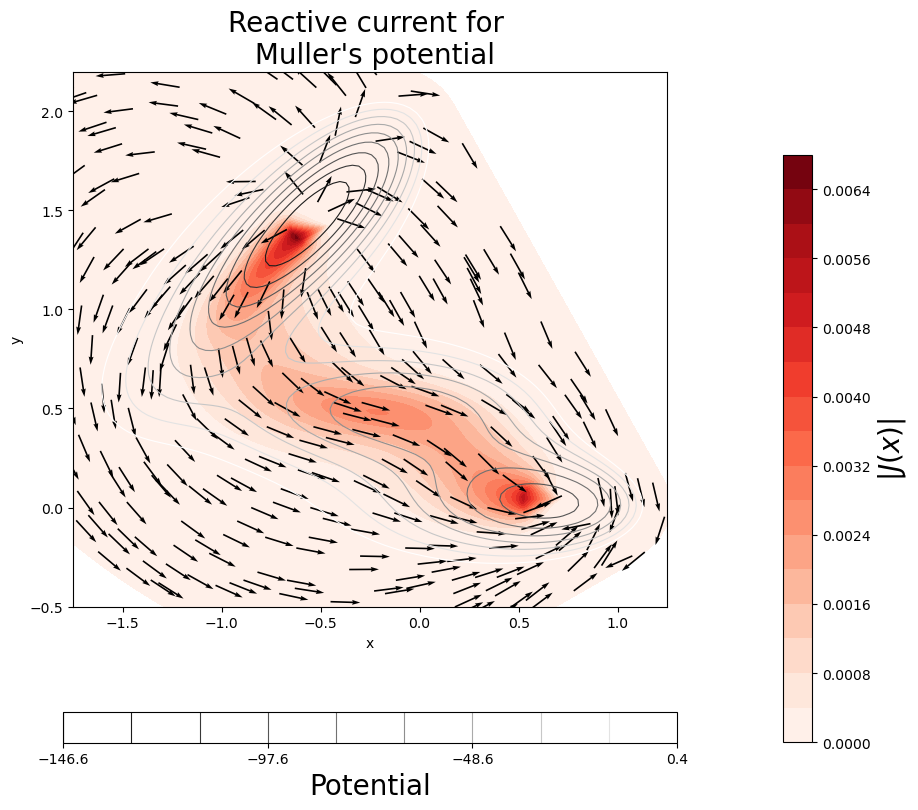

In [24]:
comm = np.linalg.norm(Rcurrent,axis = 1).squeeze()
x, y = pts[:, 0], pts[:, 1]

# (a) Filled contour of committor on the point cloud (Delaunay triangulation)
fig_a, ax_a = plt.subplots(figsize=(10, 9))
tri_mesh = Delaunay(pts)
tc = ax_a.tricontourf(x, y, comm, levels=20, cmap="Reds")

# Muller potential level sets (same grid/levels style as helpers.plot_density)
nx, ny = 128, 128
xx = np.linspace(x.min(), x.max(), nx)
yy = np.linspace(y.min(), y.max(), ny)
XX, YY = np.meshgrid(xx, yy, indexing="xy")
potential_grid = np.vectorize(lambda a, b: helpers.muller_potential([a, b]))(XX, YY)
grid_min = np.min(potential_grid)
potential_levels = np.linspace(grid_min, 0.4, 10)
norm_pot = plt.Normalize(vmin=grid_min, vmax=0.4)
pot_cf = ax_a.contour(
    XX,
    YY,
    potential_grid,
    levels=potential_levels,
    cmap="gist_gray",
    norm=norm_pot,
    linewidths=0.8,
)

# quivers: normalized reactive current
scale_factor = 0.05
normalized_Rcurrent = scale_factor*Rcurrent/np.linalg.norm(Rcurrent,axis = 1).reshape(-1,1)
ax_a.quiver(pts[::100,0],pts[::100,1],normalized_Rcurrent[::100,0],normalized_Rcurrent[::100,1],scale = 1)

# Colorbars: committor (side) and potential (bottom), shortened vs. axes for readability
shrink = 0.78
cbar_com = fig_a.colorbar(tc, ax=ax_a, shrink=shrink, pad=0.02)
cbar_com.set_label(r"$ |J(x)|$", fontsize=20)
cbar_pot = fig_a.colorbar(
    pot_cf,
    ax=ax_a,
    orientation="horizontal",
    shrink=shrink,
    pad=0.14
)
cbar_pot.set_ticks(np.linspace(grid_min, 0.4, 4))
cbar_pot.set_label("Potential", fontsize=20)
ax_a.set_xlabel("x")
ax_a.set_ylabel("y")
ax_a.set_title(f"Reactive current for \n Muller's potential", fontsize=20)
ax_a.set_aspect("equal")
xmin, xmax = -1.75, 1.25
ymin, ymax = -0.5, 2.20
ax_a.set_xlim(xmin, xmax)
ax_a.set_ylim(ymin, ymax)
fig_a.tight_layout(rect=[0, 0.06, 1, 1])

In [73]:
normalized_Rcurrent = np.diag(1/np.linalg.norm(Rcurrent,axis = 1).squeeze())@Rcurrent

In [75]:
np.linalg.norm(normalized_Rcurrent,axis = 1)

array([1., 1., 1., ..., 1., 1., 1.])